<h1 align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
جرم‌شناسی
</font>
</h1>




<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مقدمه و صورت مسئله
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
هدف شما در این مسئله، ایجاد یک مدل پیش‌بینی است که می‌تواند از داده‌های تاریخی حوادث جدید را در یکی از چندین دسته جرم طبقه‌بندی کند. این مدل باید به سازمان‌های مجری قانون کمک کند تا الگوهای رفتار مجرمانه را شناسایی کرده و تصمیمات آگاهانه‌تری در مورد استراتژی‌های پیشگیری از جرم در لس‌آنجلس بگیرند.
</font>
</p>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
معرفی مجموعه داده
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
مجموعه داده آموزشی شامل 84113 سطر است که در جدول زیر، توضیحات هر ستون آمده است.
</font>
</p>

<center>
<div dir=rtl style="direction: rtl;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    
|ستون|توضیحات|
|:------:|:---:|
|DR_NO| یک شناسه‌ی منحصر به فرد برای هر گزارش جرم|
|Date Rptd| تاریخ گزارش جنایت|
|DATE OCC| تاریخ وقوع جرم|
|TIME OCC| زمان وقوع جرم|
|AREA| کد منطقه‌ای که جرم در آن رخ داده است|
|AREA NAME| نام منطقه‌ای که جرم در آن رخ داده است|
|Rpt Dist No| شماره‌ی منطقه‌ی گزارش‌دهنده|
|Crm Cd| کد جرم که نشان‌دهنده‌ی دسته‌ی جرم است (این ستون، متغیر هدف است)|
|Crm Cd Desc| شرح جرم|
|Mocodes| کدهای نشان‌دهنده‌ی روش مورد استفاده برای ارتکاب جرم|
|Vict Age| سن قربانی|
|Vict Sex| جنسیت قربانی|
|Vict Descent| قومیت/تبار قربانی|
|Premis Cd| کد نوع محل وقوع جرم|
|Premis Desc| شرحی از محل|
|Weapon Used Cd| کد نوع سلاح مورد استفاده در جرم|
|Weapon Desc| شرحی از سلاح مورد استفاده|
|Status| وضعیت پرونده (به عنوان مثال، در دست بررسی، بسته‌شده)|
|Status Desc| شرح وضعیت پرونده|
|Crm Cd 1، Crm Cd 2، Crm Cd 3، Crm Cd 4| کدهای جرم اضافی در صورتی که حادثه شامل چندین جرم باشد|
|LOCATION| طول و عرض جغرافیایی جنایت|
|Cross Street| نزدیکترین چهارراه به محل وقوع جرم|
|LAT| مختصات عرض جغرافیایی جرم|
|LON| مختصات طول جغرافیایی جرم|

    
</font>
</div>
</center>


<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
    مجموعه‌داده‌ی آزمایش نیز مانند مجموعه‌ی آموزش است با این تفاوت که ستون <code>Crm Cd</code> که متغیر هدف مسئله است را در خود ندارد. همچنین ستون‌های <code>Crm Cd 1</code> و <code>Crm Cd 2</code> و  <code>Crm Cd 3</code> و <code>Crm Cd 4</code> و <code>Crm Cd Desc</code> که اطلاعات مستقیم در مورد متغیر هدف دارند را نیز در خود ندارد. مجموعه‌داده‌ی آزمایش 9346 سطر و 21 ستون دارد.
</font>
</p>


## read data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_train = pd.read_csv("../data/train.csv")
df_test = pd.read_csv("../data/test.csv")

df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 84113 entries, 0 to 84112
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   DR_NO           84113 non-null  int64  
 1   Date Rptd       84113 non-null  str    
 2   DATE OCC        84113 non-null  str    
 3   TIME OCC        84113 non-null  int64  
 4   AREA            84113 non-null  int64  
 5   AREA NAME       84113 non-null  str    
 6   Rpt Dist No     84113 non-null  int64  
 7   Crm Cd          84113 non-null  int64  
 8   Crm Cd Desc     84113 non-null  str    
 9   Mocodes         70368 non-null  str    
 10  Vict Age        84113 non-null  int64  
 11  Vict Sex        70589 non-null  str    
 12  Vict Descent    70588 non-null  str    
 13  Premis Cd       84111 non-null  float64
 14  Premis Desc     84082 non-null  str    
 15  Weapon Used Cd  29721 non-null  float64
 16  Weapon Desc     29721 non-null  str    
 17  Status          84113 non-null  str    
 1

In [3]:
df_train["Vict Age"] = df_train["Vict Age"].replace(0, np.nan)

In [4]:
df_train["Weapon Desc"].value_counts()

Weapon Desc
STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)    16705
UNKNOWN WEAPON/OTHER WEAPON                        3305
VERBAL THREAT                                      2276
HAND GUN                                           1520
SEMI-AUTOMATIC PISTOL                               594
                                                  ...  
STRAIGHT RAZOR                                        1
M1-1 SEMIAUTOMATIC ASSAULT RIFLE                      1
BOMB THREAT                                           1
RELIC FIREARM                                         1
AUTOMATIC WEAPON/SUB-MACHINE GUN                      1
Name: count, Length: 71, dtype: int64

## time feature eng

In [ ]:
def time_handle(df):
    df["TIME OCC"] = (
        pd.to_datetime(
            df["TIME OCC"].astype(str).str.zfill(4),
            format="%H%M"
        )
        .dt.round("60min")
        .dt.strftime("%H")
        .astype(int)
    )
    df["DATE OCC"] = pd.to_datetime(df["DATE OCC"])
    df["Date Rptd"] = pd.to_datetime(df_train["Date Rptd"])
    df["time_to_report"] = (df["Date Rptd"] - df["DATE OCC"]).dt.days
    df = df[df["time_to_report"].quantile(0.95) > df["time_to_report"]]
    return df

df_train = time_handle(df_train)
df_test = time_handle(df_test)



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30820\3151235850.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DATE OCC"] = pd.to_datetime(df["DATE OCC"])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30820\3151235850.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date Rptd"] = pd.to_datetime(df_train["Date Rptd"])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30820\3151235850.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DATE OCC"] = pd.to_datetime(df["DATE OCC"])


## area feature eng

In [ ]:
def area_handle(df):
    df["LOCATION"] = (
        df["LOCATION"]
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    df["Cross Street"] = (
        df["Cross Street"]
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    # street name
    df["street_name"] = df["LOCATION"].str.replace(
        r"\s+(ST|AV|BL|WY|PL|DR|RD|HWY|CT|LN|PKWY)$",
        "",
        regex=True
    )

    # street type
    df["street_type"] = df["LOCATION"].str.extract(
        r"\b(ST|AV|BL|WY|PL|DR|RD|HWY|CT|LN|PKWY)\b$"
    )

    # Cross Street
    df["Cross Street"] = df["Cross Street"].str.replace(
        r"\s+(ST|AV|BL|WY|PL|DR|RD|HWY|CT|LN|PKWY)$",
        "",
        regex=True
    )

    # threshold for street_name
    street_counts = df["street_name"].value_counts()
    top_streets = street_counts[street_counts > 10].index

    df["street_name"] = df["street_name"].where(
        df["street_name"].isin(top_streets),
        "Other"
    )

    # threshold for Cross Street
    cross_counts = df["Cross Street"].value_counts()
    top_cross = cross_counts[cross_counts > 10].index

    df["Cross Street"] = df["Cross Street"].where(
        df["Cross Street"].isin(top_cross),
        "Other"
    )

    return df

df_train = area_handle(df_train)
df_test = area_handle(df_test)

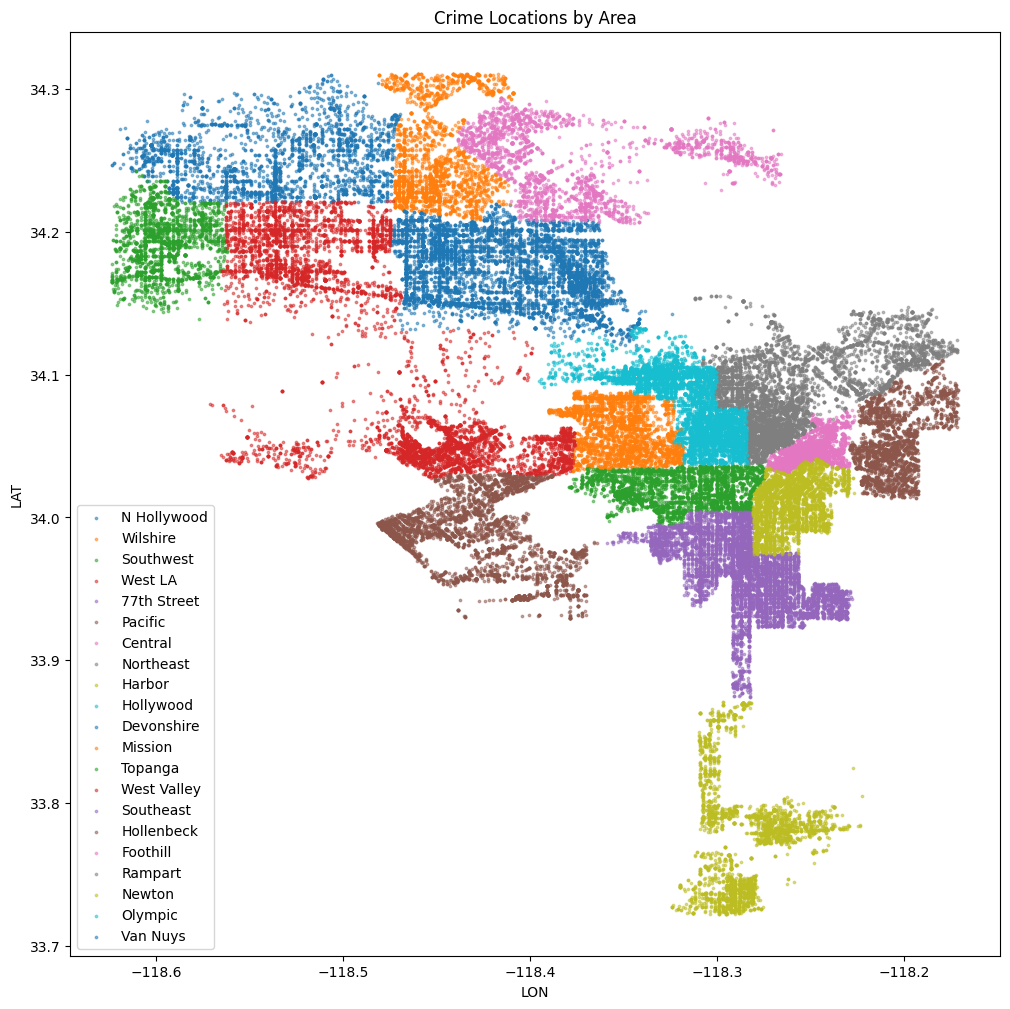

In [ ]:
low_lat = df_train["LAT"].quantile(0.005)
high_lat = df_train["LAT"].quantile(0.995)

low_lon = df_train["LON"].quantile(0.005)
high_lon = df_train["LON"].quantile(0.995)

df_train = df_train[
    (df_train["LAT"] >= low_lat) &
    (df_train["LAT"] <= high_lat) &
    (df_train["LON"] >= low_lon) &
    (df_train["LON"] <= high_lon) 
]

df_test = df_test[
    (df_test["LAT"] >= low_lat) &
    (df_test["LAT"] <= high_lat) &
    (df_test["LON"] >= low_lon) &
    (df_test["LON"] <= high_lon) 
]

plt.figure(figsize=(12, 12))

for area in df_train["AREA NAME"].unique():
    data = df_train[df_train["AREA NAME"] == area]
    
    plt.scatter(
        data["LON"],
        data["LAT"],
        s=3,
        alpha=0.5,
        label=area
    )

plt.xlabel("LON")
plt.ylabel("LAT")
plt.title("Crime Locations by Area")
plt.legend()
plt.show()

## numeric features

In [ ]:
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor


In [ ]:
num_cols = [
    "Vict Age",
    "LAT",
    "LON",
    "AREA",
    "time_to_report"
]

imputer = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    max_iter=10,
    random_state=42
)

df_train[num_cols] = imputer.fit_transform(df_train[num_cols])
df_test[num_cols] = imputer.transform(df_test[num_cols])

## crm

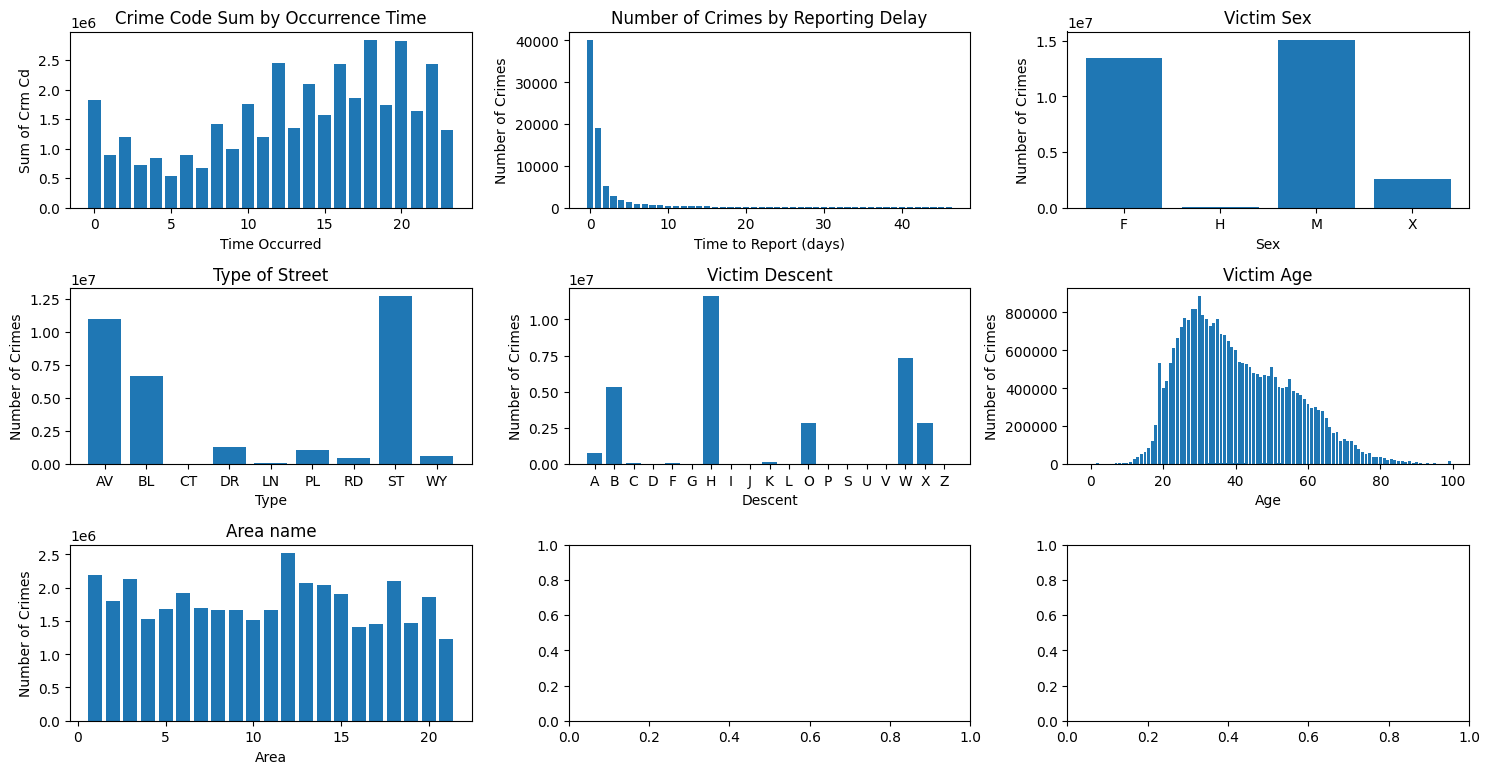

In [ ]:
Crm_street = df_train.groupby("street_type")["Crm Cd"].sum()
Crm_Time = df_train.groupby("TIME OCC")["Crm Cd"].sum()
Crm_RptTime = df_train["time_to_report"].value_counts().sort_index()
Crm_descent = df_train.groupby("Vict Descent")["Crm Cd"].sum()
Crm_sex = df_train.groupby("Vict Sex")["Crm Cd"].sum()
Crm_age = df_train.groupby("Vict Age")["Crm Cd"].sum()
Crm_area = df_train.groupby("AREA")["Crm Cd"].sum()



fig, axs = plt.subplots(3, 3, figsize=(15, 8))

# Plot 1
axs[0,0].bar(Crm_Time.index, Crm_Time.values)
axs[0,0].set_xlabel("Time Occurred")
axs[0,0].set_ylabel("Sum of Crm Cd")
axs[0,0].set_title("Crime Code Sum by Occurrence Time")

# Plot 2
axs[0,1].bar(Crm_RptTime.index, Crm_RptTime.values)
axs[0,1].set_xlabel("Time to Report (days)")
axs[0,1].set_ylabel("Number of Crimes")
axs[0,1].set_title("Number of Crimes by Reporting Delay")

# PLot 3
axs[1,0].bar(Crm_street.index, Crm_street.values)
axs[1,0].set_xlabel("Type")
axs[1,0].set_ylabel("Number of Crimes")
axs[1,0].set_title("Type of Street")

# PLot 4
axs[1,1].bar(Crm_descent.index, Crm_descent.values)
axs[1,1].set_xlabel("Descent")
axs[1,1].set_ylabel("Number of Crimes")
axs[1,1].set_title("Victim Descent")

# PLot 5
axs[0,2].bar(Crm_sex.index, Crm_sex.values)
axs[0,2].set_xlabel("Sex")
axs[0,2].set_ylabel("Number of Crimes")
axs[0,2].set_title("Victim Sex")

# PLot 6
axs[1,2].bar(Crm_age.index, Crm_age.values)
axs[1,2].set_xlabel("Age")
axs[1,2].set_ylabel("Number of Crimes")
axs[1,2].set_title("Victim Age")

axs[2,0].bar(Crm_area.index, Crm_area.values)
axs[2,0].set_xlabel("Area")
axs[2,0].set_ylabel("Number of Crimes")
axs[2,0].set_title("Area name")

plt.tight_layout()
plt.show()


In [ ]:
df_train

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Crm Cd,Crm Cd Desc,Mocodes,...,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON,time_to_report,street_name,street_type
0,201516407,2020-10-17,2020-10-15,21,15.0,N Hollywood,1581,510,VEHICLE - STOLEN,NaN,...,NaN,NaN,NaN,4300 WHITSETT AV,Other,34.1486,-118.4052,2.0,Other,AV
1,200700622,2020-03-24,2020-03-24,14,7.0,Wilshire,705,626,INTIMATE PARTNER - SIMPLE ASSAULT,0416 1814 1402,...,998.0,NaN,NaN,800 N ALTA VISTA BL,Other,34.0853,-118.3475,0.0,Other,BL
2,200312712,2020-06-14,2020-06-14,10,3.0,Southwest,362,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",1251 1259 2024 1815 0554 0334 0913 0400 1402,...,NaN,NaN,NaN,4600 OBAMA BL,Other,34.0170,-118.3477,0.0,Other,BL
3,201515083,2020-09-12,2020-09-08,15,15.0,N Hollywood,1585,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",0325 0216,...,NaN,NaN,NaN,11200 W VENTURA BL,Other,34.1430,-118.3727,4.0,Other,BL
4,200817552,2020-12-14,2020-12-14,8,8.0,West LA,853,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0329 1822,...,NaN,NaN,NaN,BARRINGTON,Other,34.0445,-118.4491,0.0,Other,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84107,200704622,2020-01-13,2020-01-13,12,7.0,Wilshire,784,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0416 0913,...,NaN,NaN,NaN,2200 S MANSFIELD AV,Other,34.0375,-118.3499,0.0,Other,AV
84108,201207833,2020-02-25,2020-02-25,21,12.0,77th Street,1211,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",1822 0400 0411 0906,...,NaN,NaN,NaN,SLAUSON AV,7TH,33.9891,-118.3247,0.0,SLAUSON,AV
84109,201208587,2020-03-06,2020-03-06,9,12.0,77th Street,1273,626,INTIMATE PARTNER - SIMPLE ASSAULT,2000 0913 1813 0337 0444,...,NaN,NaN,NaN,2000 W MANCHESTER AV,Other,33.9600,-118.3134,0.0,Other,AV
84110,201819827,2020-10-31,2020-10-31,0,18.0,Southeast,1842,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",1822 1300 1309 0416 0400 1206 2033,...,NaN,NaN,NaN,111TH ST,SAN PEDRO,33.9348,-118.2695,0.0,111TH,ST


## encode

In [ ]:
df_train = df_train[df_train["Vict Sex"] != "H"]

df_train["Vict Sex"] = df_train["Vict Sex"].map({
    "M": 1,
    "F": -1,
    "X": 0
})


df_test = df_test[df_test["Vict Sex"] != "H"]

df_test["Vict Sex"] = df_test["Vict Sex"].map({
    "M": 1,
    "F": -1,
    "X": 0
})


In [ ]:
codes = (
    df_train["Mocodes"]
    .dropna()
    .str.split()
    .explode()
)

top_50 = (
    df_train["Mocodes"]
    .fillna("")
    .str.split()
    .explode()
    .value_counts()
    .head(50)
    .index
)

mocodes_encoded = (
    df_train["Mocodes"]
    .fillna("")
    .str.get_dummies(sep=" ")
    .reindex(columns=top_50, fill_value=0)
)

df_train = pd.concat(
    [
        df_train.drop(columns=["Mocodes"]),
        mocodes_encoded
    ],
    axis=1
)


test_mocodes = (
    df_test["Mocodes"]
    .fillna("")
    .str.get_dummies(sep=" ")
    .reindex(columns=top_50, fill_value=0)
)

df_test = pd.concat(
    [
        df_test.drop(columns=["Mocodes"]),
        test_mocodes
    ],
    axis=1
)

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
معیار ارزیابی
</font>
</h3>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
 معیار ارزیابی مورد استفاده در داوری این مسئله، امتیاز <code>F1 Macro</code> است که دقت و بازیابی را در تمام دسته‌های جرم به صورت متعادل‌شده بررسی می‌کند. بر خلاف دقت، که می تواند توسط داده‌های نامتعادل تغییر کند، امتیاز <code>F1 Macro</code>، امتیاز <code>F1</code> را برای هر دسته‌ی جرم به طور مستقل محاسبه می‌کند و سپس میانگین آن‌ها را محاسبه می‌کند. این معیار تضمین می‌کند که عملکرد در دسته‌های جرایم کم‌تکرار اهمیت یکسانی دارد. این ویژگی این معیار را برای پیش‌بینی انواع مختلف جرایم، صرف نظر از فراوانی آنها در مجموعه‌داده، مناسب می‌سازد.
</font>
</p>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
 پیش‌بینی برای داده تست و خروجی
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    از مدل خود برای پیش‌بینی نمونه‌های موجود در داده‌ی تست استفاده کنید و نتایج را در قالب جدولی (<code>dataframe</code>) به شکل زیر آماده کنید.
</font>
</p>

<div dir=rtl style="direction: rtl;text-align: center;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    
|ستون|توضیحات|
|------|---|
|Crm Cd|کد جرم پیش‌بینی‌شده|
    
</font>
</div>



<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    اسم دیتافریم باید <i>submission</i> باشد؛ در غیر این صورت، سامانه داوری نمی‌تواند تلاش‌ شما را ارزیابی کند.
    <br>
    این دیتافریم تنها شامل ۱ ستون با اسم <i>Crm Cd</i> است و ? سطر دارد.
    <br>
    به ازای هر سطر موجود در دیتافریم <i>test</i> شما باید یک مقدار پیشبینی شده داشته باشید.
    <br>
    جدول زیر، ۵ سطر ابتدایی دیتافریم <code>submission</code> را نشان می‌دهد. البته در جواب شما، مقادیر ستون <i>Crm Cd</i> ممکن است متفاوت باشد.
</font>
</p>

<div style="text-align: center;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    
|Crm Cd|
|-----|
|210|
|420|
|930|
|624|
|420|

</font>
</div>

In [ ]:
# predict test samples
submission =

SyntaxError: invalid syntax (1015814745.py, line 2)

<h2 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
<b>سلول جواب‌ساز</b>
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
    برای ساخته‌شدن فایل <code>result.zip</code> سلول زیر را اجرا کنید. توجه داشته باشید که پیش از اجرای سلول زیر تغییرات اعمال شده در نت‌بوک را ذخیره کرده باشید (<code>ctrl+s</code>) در غیر این صورت، در پایان مسابقه نمره شما به صفر تغییر خواهد کرد.
    <br>
    همچنین اگر از کولب برای اجرای این فایل نوت‌بوک استفاده می‌کنید، قبل از ارسال فایل <code>result.zip</code>، آخرین نسخه‌ی نوت‌بوک خود را دانلود کرده و داخل فایل ارسالی قرار دهید.
</font>

In [ ]:
import zipfile
import joblib

if not os.path.exists(os.path.join(os.getcwd(), 'crime-detection.ipynb')):
    %notebook -e crime-detection.ipynb

def compress(file_names):
    print("File Paths:")
    print(file_names)
    compression = zipfile.ZIP_DEFLATED
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            zf.write('./' + file_name, file_name, compress_type=compression)

submission.to_csv('submission.csv', index=False)
file_names = ['crime-detection.ipynb', 'submission.csv']
compress(file_names)